# Student Performance Indicator

## Life Cycle of Machine Learning Project

- Understanding the problem statement
- Data collection
- Data checks to perform
- EDA
- Data pre-processing
- Model training
- Choose best model

## 1. Problem Statement

The project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, lunch and test prep course

## 2. Data Collection

Data is collected from Kaggle. Data consists of 8 columns and 1000 rows

## 2.1 Import Data and required packages

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

### Import the CSV data as df

In [3]:
df = pd.read_csv('data/stud.csv')

### Show head of the df

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Show shape of the df

In [5]:
df.shape

(1000, 8)

## 3. Datachecks to perform

- Check missing values
- Check duplicates
- Check data type
- Check number of unique values of each column
- Check statistics of dataset
- Check variousbcategories present in the different categorical column

In [6]:
# check missing values
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
# check duplicates
df[df.duplicated()]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


In [8]:
# check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
# check number of unique values of each column
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
# check statistics of dataset
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
# check various categories present in the different categorical column

# it means check unique values in each column

for e in list(df.columns):
    print(f"Catgories in '{e}' column: \n")
    print(df[e].unique())
    print('\n')

Catgories in 'gender' column: 

['female' 'male']


Catgories in 'race_ethnicity' column: 

['group B' 'group C' 'group A' 'group D' 'group E']


Catgories in 'parental_level_of_education' column: 

["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


Catgories in 'lunch' column: 

['standard' 'free/reduced']


Catgories in 'test_preparation_course' column: 

['none' 'completed']


Catgories in 'math_score' column: 

[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]


Catgories in 'reading_score' column: 

[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  3

### Segregate numerical and object type columns

In [12]:
numeric_features = [c for c in df.columns if df[c].dtype!='O']
categorical_features = [c for c in df.columns if df[c].dtype=='O']

print(f"We have {len(numeric_features)} numeric features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numeric features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### Creating 'Total Score' and 'Average Score'

In [13]:
df['total score'] = 0
for c in numeric_features:
    df['total score'] = df['total score'] + df[c]


In [14]:
df['average'] = df['total score']/3

In [15]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading_score']==100]['reading_score'].count()
writing_full = df[df['writing_score']==100]['writing_score'].count()
math_full = df[df['math_score']==100]['math_score'].count()

print(f"Students with full marks in maths: {math_full}")
print(f"Students with full marks in reading: {reading_full}")
print(f"Students with full marks in writing: {writing_full}")

Students with full marks in maths: 7
Students with full marks in reading: 17
Students with full marks in writing: 14


In [17]:
reading_less_20 = df[df['reading_score']<=20]['reading_score'].count()
writing_less_20 = df[df['writing_score']<=20]['writing_score'].count()
math_less_20 = df[df['math_score']<=20]['math_score'].count()

print(f"Students with less than 20 in maths: {math_less_20}")
print(f"Students with less than 20 in writing: {writing_less_20}")
print(f"Students with less than 20 in reading: {reading_less_20}")

Students with less than 20 in maths: 4
Students with less than 20 in writing: 3
Students with less than 20 in reading: 1


### Visualisation

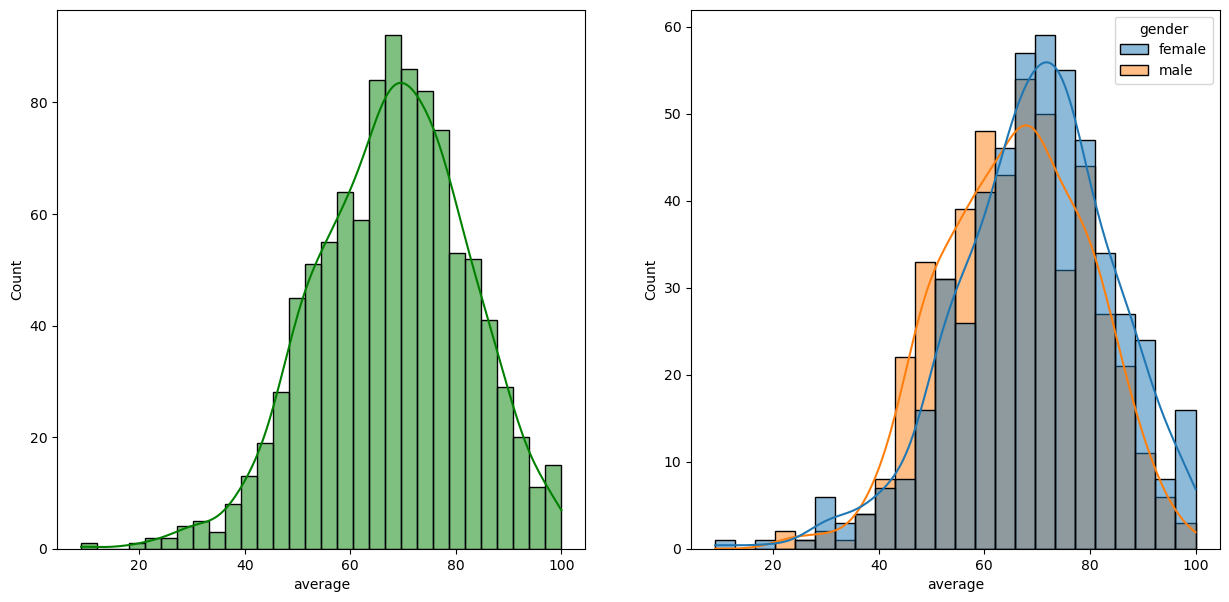

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.show()

### Insights

Females are performing better than male students

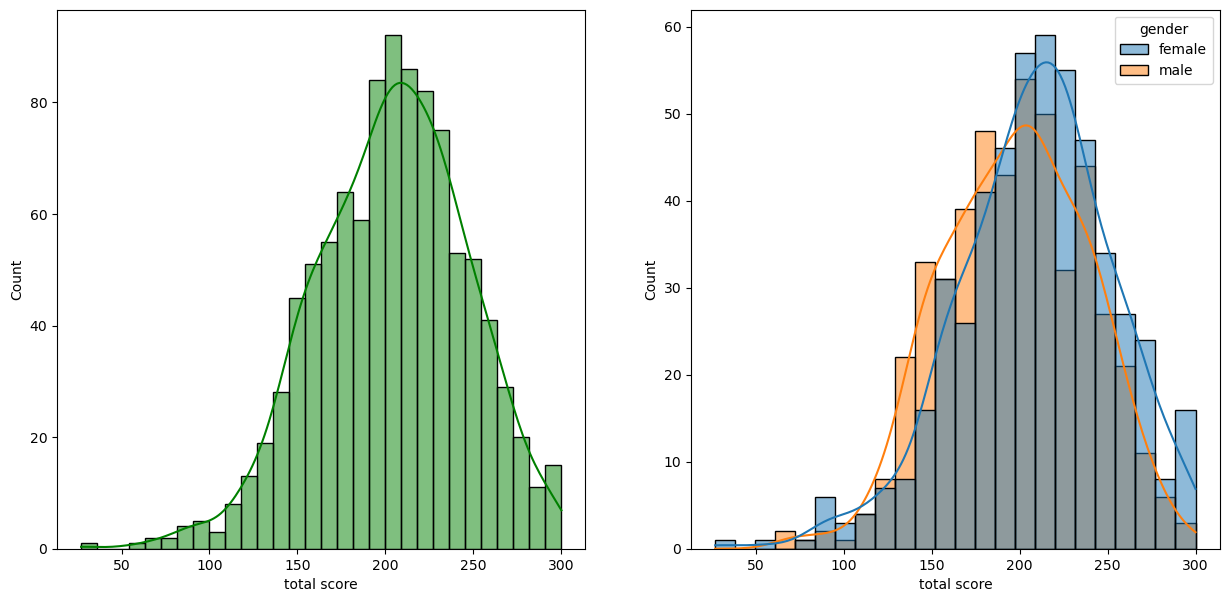

In [19]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total score', kde=True, hue='gender')
plt.show()

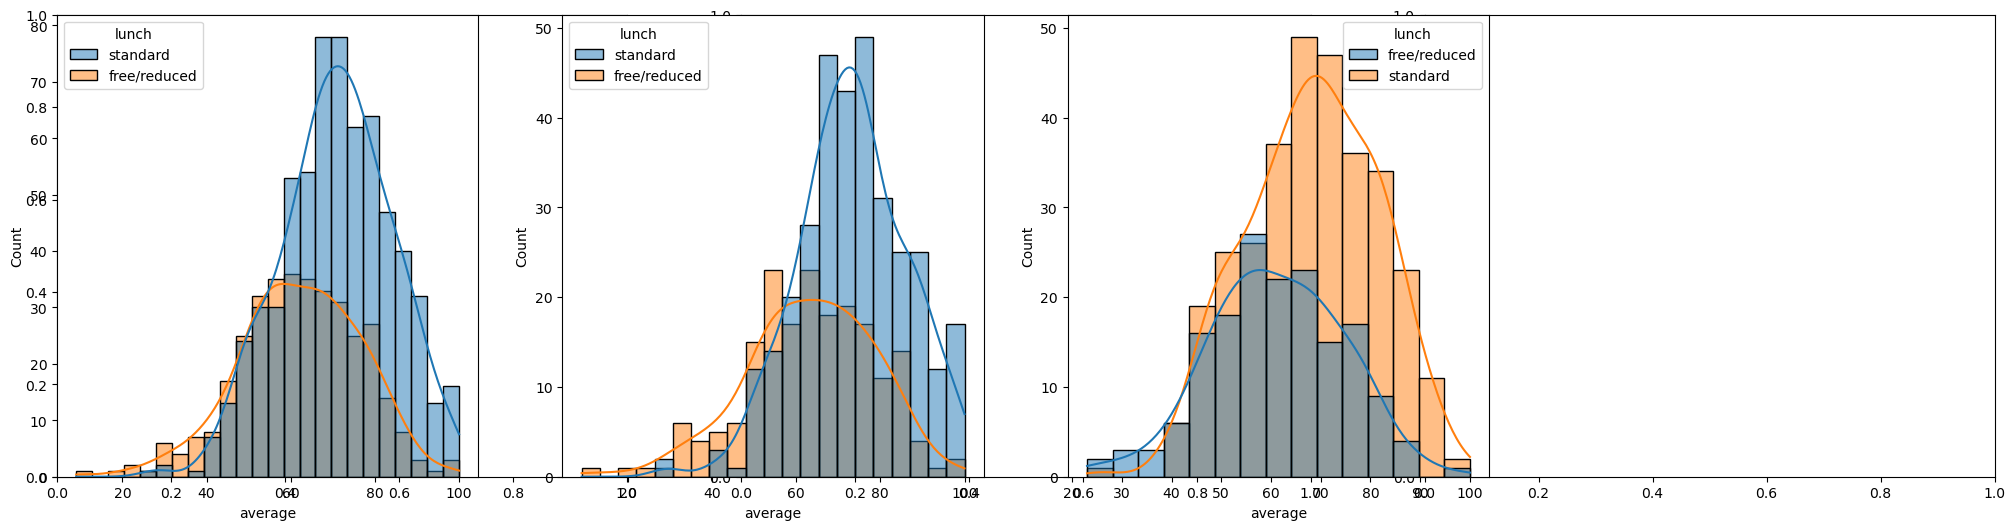

In [20]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df['gender']=='female'], x='average', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df['gender']=='male'], x='average', kde=True, hue='lunch')
plt.show()

### Insights

Standard lunch helps in performing well in exams be it male female or in general

In [21]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total score', 'average'],
      dtype='object')

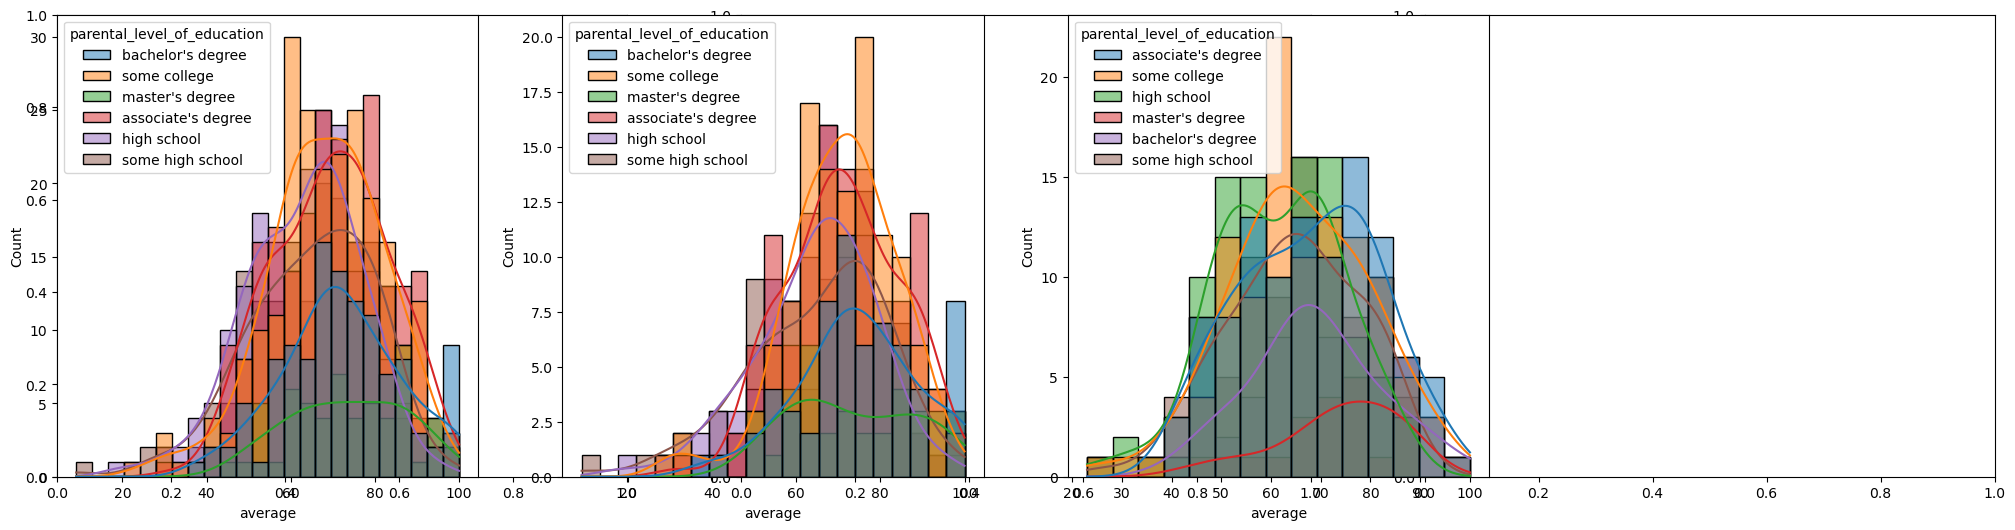

In [22]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education')
plt.subplot(142)
sns.histplot(data=df[df['gender']=='female'], x='average', kde=True, hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df['gender']=='male'], x='average', kde=True, hue='parental_level_of_education')
plt.show()

### Analysis

- First plot shows there is no direct corelation between parental level education and student marks

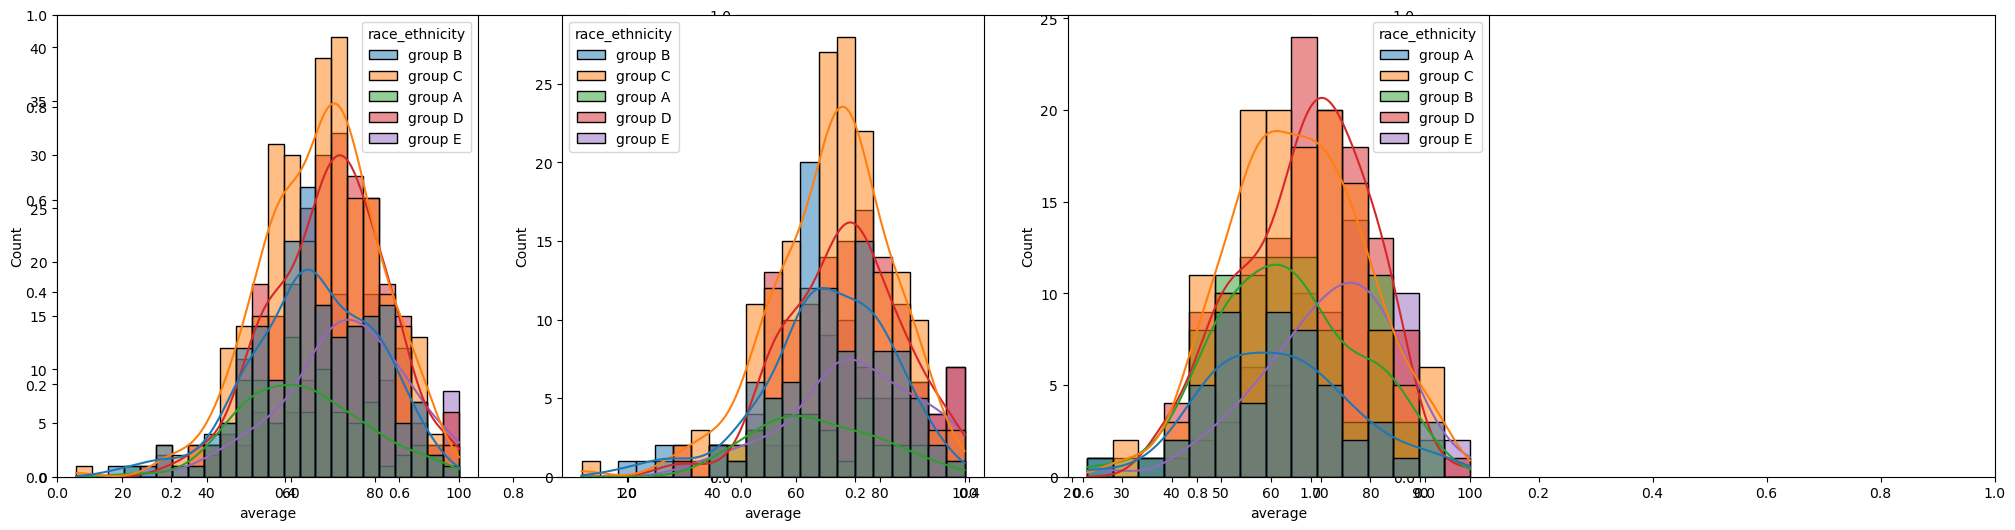

In [23]:
field = 'race_ethnicity'

plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue=field)
plt.subplot(142)
sns.histplot(data=df[df['gender']=='female'], x='average', kde=True, hue=field)
plt.subplot(143)
sns.histplot(data=df[df['gender']=='male'], x='average', kde=True, hue=field)
plt.show()

### Insights
- Group C and D do good

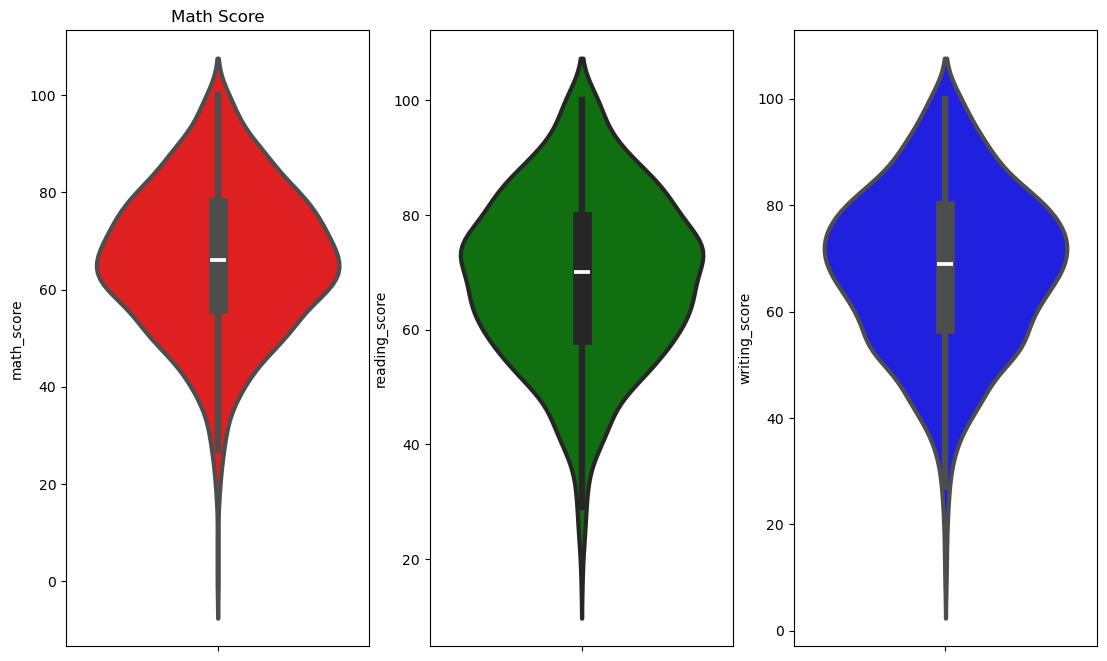

In [24]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math Score')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)
plt.subplot(1,4,2)
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)
plt.subplot(1,4,3)
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)
plt.show()

### Insights

Students usually score in between 60-80

In [25]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total score', 'average'],
      dtype='object')

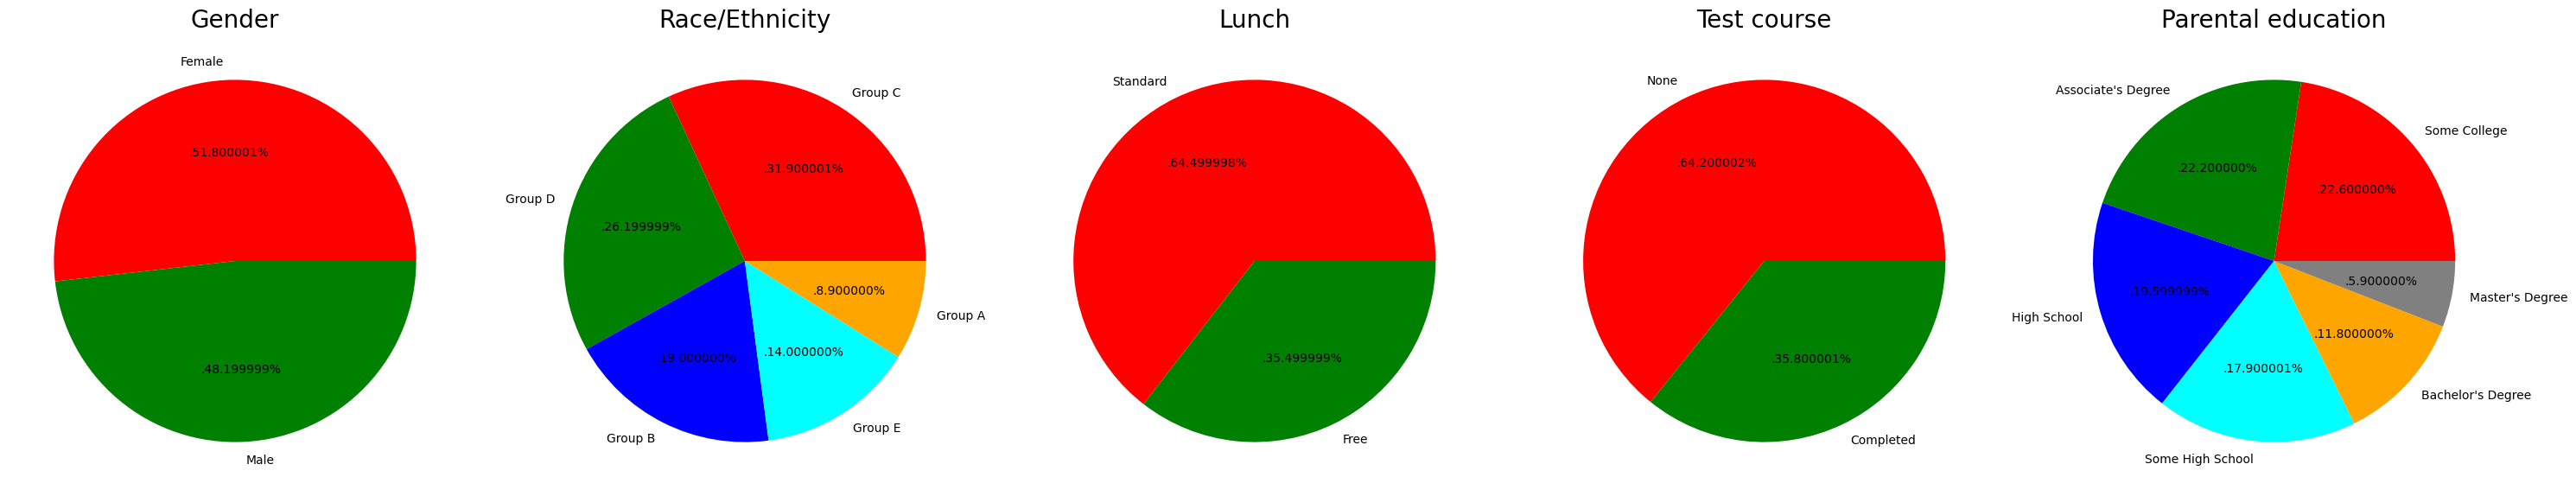

In [26]:
# Multivariate Analysis

plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'Standard','Free'
color = ['red','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size = df['test_preparation_course'].value_counts()
labels = 'None','Completed'
color = ['red','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Test course', fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Parental education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

# Feature Wise Visualization

## Gender Column

- How is distribution of Gender?
- Does gender have any impact on student's performance?

## Univariate Analysis (How is distribution of Gender?)

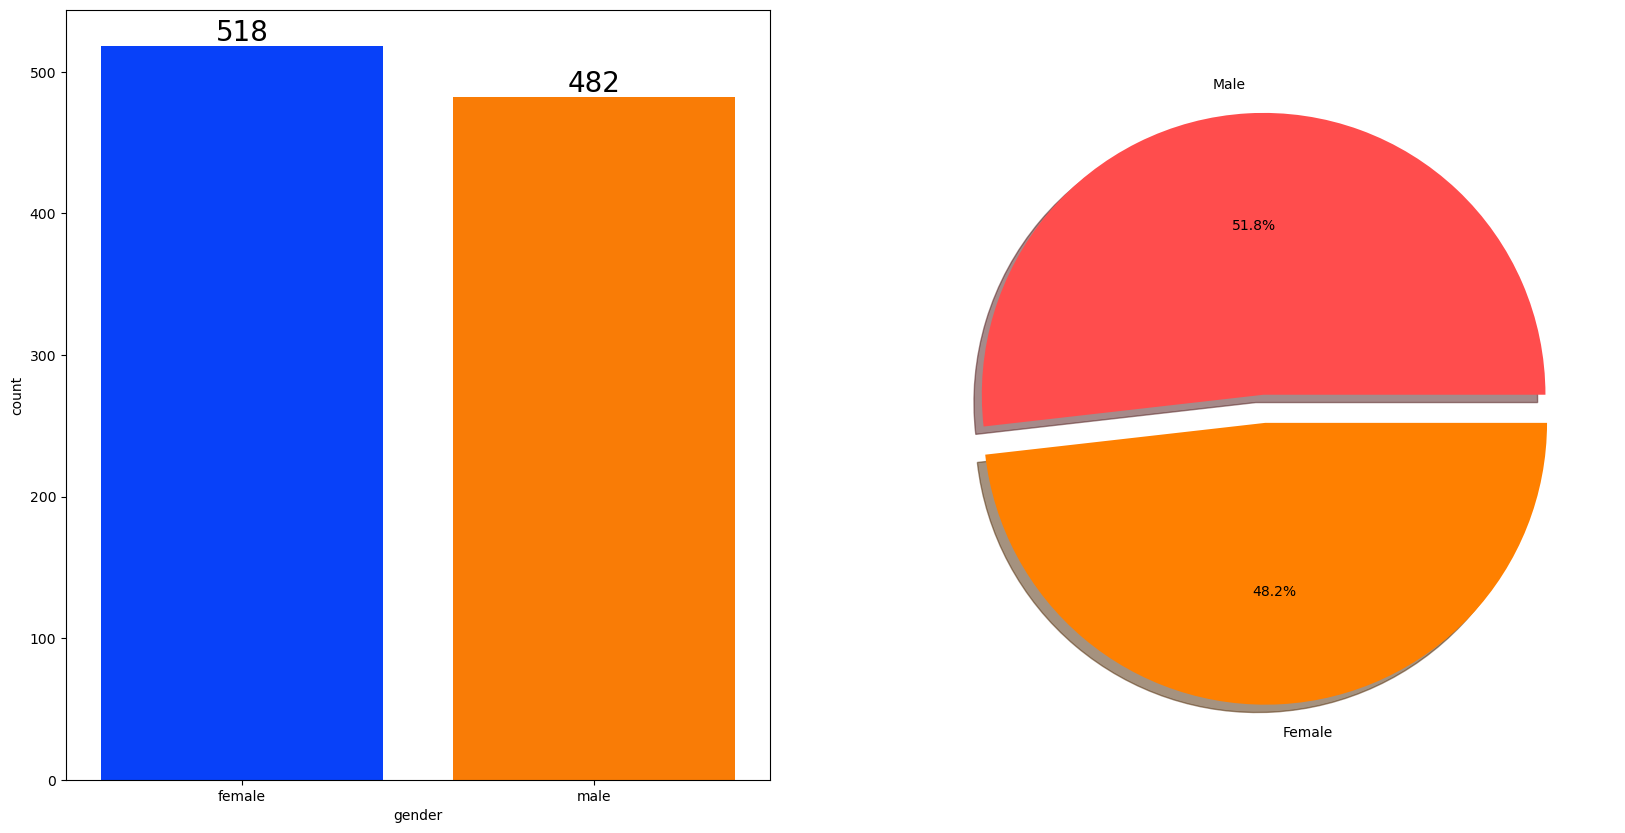

In [27]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

plt.pie(x=df['gender'].value_counts(), labels=['Male','Female'], explode=[0,0.1], autopct='%1.1f%%',shadow=True, colors=['#ff4d4d','#ff8000'])
plt.show()